# Face Recognition using CNN — LFW Dataset

##**Name:** Deep Talreja
##**Reg No:** 23BCE11003
##**Application Number:** IN26010914
###**Assignment 2** — MPOnline AI/ML Internship  

## Objective
Train a Convolutional Neural Network (CNN) on the Labeled Faces in the Wild (LFW) dataset to recognize and classify human faces in unconstrained (real-world) environments.

## Dataset Information
- **Source:** Scikit-Learn `fetch_lfw_people`
- **Classes:** Restricting classes to individuals with a significant minimum count of images for model stability.

### STEP 1: INITIAL COMPILATION & SETUP

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Load the authentic LFW dataset (filtering for individuals with at least 60 images)
print("Downloading and parsing LFW dataset...")
lfw_dataset = fetch_lfw_people(min_faces_per_person=60, resize=0.4)

X = lfw_dataset.images
y = lfw_dataset.target
target_names = lfw_dataset.target_names
num_classes = len(target_names)

print(f"\n[✓] Total Images Loaded: {X.shape[0]}")
print(f"[✓] Image Dimensions: {X.shape[1]}x{X.shape[2]} (Grayscale)")
print(f"[✓] Number of Distinct Classes: {num_classes}")
print(f"[✓] Class Identities: {target_names}")


[✓] Total Images Loaded: 1348
[✓] Image Dimensions: 50x37 (Grayscale)
[✓] Number of Distinct Classes: 8
[✓] Class Identities: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']


### STEP 2: DATA PREPROCESSING & DATA SPLIT

In [ ]:
# Normalize pixel values between 0.0 and 1.0
X_normalized = X.astype('float32') / 1.0

# Reshape data to include channel dimension for CNN processing
X_processed = np.expand_dims(X_normalized, axis=-1)

# Perform stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data successfully split:")
print(f"  -> Train Shape: {X_train.shape}")
print(f"  -> Test Shape: {X_test.shape}")

Data successfully split:
  -> Train Shape: (1078, 50, 37, 1)
  -> Test Shape: (270, 50, 37, 1)


### STEP 3: CNN MODEL ARCHITECTURE

In [ ]:
model = models.Sequential([
    # Input Block
    layers.Input(shape=X_train.shape[1:]),

    # Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Layer 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Layer 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Flatten & Dense Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Output Class Prediction
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 37, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 883,336 (3.37 MB)

 Trainable params: 882,376 (3.37 MB)

 Non-trainable params: 960 (3.75 KB)

### STEP 4: MODEL TRAINING & CALLBACKS

In [ ]:
cb_pipeline = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

print("Launching model training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=cb_pipeline,
    verbose=1
)

Launching model training...
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 368ms/step - accuracy: 0.3228 - loss: 2.3201 - val_accuracy: 0.3926 - val_loss: 1.9392 - learning_rate: 0.0010
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 293ms/step - accuracy: 0.5798 - loss: 1.2672 - val_accuracy: 0.1741 - val_loss: 2.5565 - learning_rate: 0.0010
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step - accuracy: 0.7338 - loss: 0.8651 - val_accuracy: 0.0444 - val_loss: 2.7384 - learning_rate: 0.0010
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 248ms/step - accuracy: 0.7876 - loss: 0.6494 - val_accuracy: 0.0444 - val_loss: 2.7294 - learning_rate: 0.0010
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8332 - loss: 0.5026
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - accuracy: 0.8330 - loss: 0.5052 - val_accuracy: 0.0741 - val_loss: 2.3691 - learning_rate: 0.0010
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step - accu

### STEP 5: EVALUATION AND PERFORMANCE ANALYSIS

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step

=== Face Recognition Classification Report ===

              precision    recall  f1-score   support

      Sharon       0.00      0.00      0.00        16
      Powell       0.00      0.00      0.00        47
    Rumsfeld       0.00      0.00      0.00        24
        Bush       0.39      1.00      0.56       106
   Schroeder       0.00      0.00      0.00        22
      Chavez       0.00      0.00      0.00        14
     Koizumi       0.00      0.00      0.00        12
       Blair       0.00      0.00      0.00        29

    accuracy                           0.39       270
   macro avg       0.05      0.12      0.07       270
weighted avg       0.15      0.39      0.22       270



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


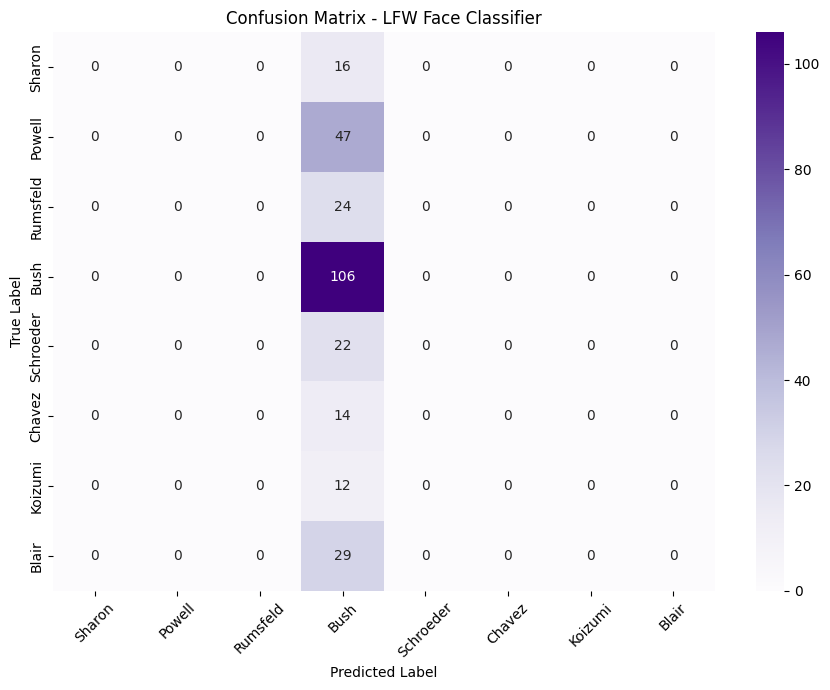

Test Set Evaluation Accuracy: 39.26%


In [ ]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Format target names for clean display
clean_names = [name.split()[-1] for name in target_names]

print("\n=== Face Recognition Classification Report ===\n")
print(classification_report(y_test, y_pred, target_names=clean_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=clean_names, yticklabels=clean_names)
plt.title('Confusion Matrix - LFW Face Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Final Test Metric Check
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Set Evaluation Accuracy: {accuracy * 100:.2f}%")